# Dự báo Volatility ngắn hạn – VN-30 (Volatility Forecasting)

**Phương pháp:** Panel Data – 1 mô hình chung trên toàn bộ 50 mã VN-30.  
**Target:** `rv5_fwd` – Realized Volatility 5 ngày tiếp theo (annualized).  
**Mô hình:** HAR-OLS (baseline), Random Forest, XGBoost, LightGBM, Quantile RF.  
**Tham khảo:** Corsi (2009), Andersen et al. (2003), Parkinson (1980), Garman-Klass (1980), Meinshausen (2006).

## 1. Import thư viện & đọc dữ liệu

In [1]:
import subprocess, sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'xgboost', 'lightgbm', 'scikit-learn', 'quantile-forest', '-q'])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
import lightgbm as lgb

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:,.4f}'.format

DATA_FILE = Path('vn30_stock_price.csv')
df_raw = pd.read_csv(DATA_FILE, parse_dates=['date'])
df_raw = df_raw.sort_values(['symbol', 'date']).reset_index(drop=True)
print(f'Shape: {df_raw.shape}')
print(f'Symbols ({df_raw.symbol.nunique()}): {sorted(df_raw.symbol.unique())}')
df_raw.head()

Shape: (96849, 7)
Symbols (50): ['ACB', 'BCM', 'BID', 'BVH', 'CII', 'CTG', 'DGC', 'DHG', 'DPM', 'EIB', 'FPT', 'GAS', 'GMD', 'GVR', 'HAG', 'HCM', 'HDB', 'HPG', 'IMP', 'KBC', 'KDC', 'LPB', 'MBB', 'MSN', 'MWG', 'NVL', 'PDR', 'PLX', 'PNJ', 'POW', 'PVD', 'PVI', 'REE', 'SAB', 'SBT', 'SHB', 'SSB', 'SSI', 'STB', 'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VND', 'VNM', 'VPB', 'VRE']


,symbol,date,open,high,low,close,volume
0,ACB,2012-02-06,3.0100,3.0100,2.9800,3.0000,137900
1,ACB,2012-02-07,3.0100,3.1500,3.0100,3.1400,607800
2,ACB,2012-02-08,3.0800,3.2200,3.0800,3.2100,510700
3,ACB,2012-02-09,3.1600,3.3900,3.1500,3.2800,1153700
4,ACB,2012-02-10,3.3000,3.3500,3.2200,3.2500,393700


## 2. Feature Engineering

| Nhóm | Biến | Nguồn khoa học |
|---|---|---|
| **HAR** | `rv_d`, `rv_w`, `rv_m` | Corsi (2009) – *Journal of Financial Econometrics* |
| **Vol Estimator** | `parkinson_vol`, `gk_vol` | Parkinson (1980), Garman-Klass (1980) |
| **Liquidity** | `amihud` | Amihud (2002) – *Journal of Financial Markets* |
| **Momentum** | `rsi_14`, `macd`, `macd_signal`, `macd_hist` | Kỹ thuật phân tích |
| **Volatility proxy** | `bb_bw`, `atr_14` | Bollinger, Wilder |
| **Lag** | `close_lag1`, `volume_lag1`, `volume_ma5` | Quá khứ 1–5 bước |
| **Temporal** | `day_of_week`, `month` | Seasonality |
| **Target** | **`rv5_fwd`** | **Forward Realized Vol 5 ngày, annualized** |

In [2]:
# ── Hàm tính chỉ báo kỹ thuật ─────────────────────────────────────────────

def compute_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = (-delta).clip(lower=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def compute_macd(close: pd.Series, fast=12, slow=26, signal=9):
    ema_fast    = close.ewm(span=fast,   adjust=False).mean()
    ema_slow    = close.ewm(span=slow,   adjust=False).mean()
    macd        = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line


def compute_bollinger_bandwidth(close: pd.Series, period=20, n_std=2) -> pd.Series:
    sma     = close.rolling(period).mean()
    std_dev = close.rolling(period).std()
    upper   = sma + n_std * std_dev
    lower   = sma - n_std * std_dev
    return (upper - lower) / sma.replace(0, np.nan)


def compute_atr(high, low, close, period=14) -> pd.Series:
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr.ewm(com=period - 1, min_periods=period).mean()


# ── Áp dụng per-symbol ────────────────────────────────────────────────────

def add_features(g: pd.DataFrame) -> pd.DataFrame:
    g = g.copy().sort_values('date')

    # ── Log return ────────────────────────────────────────────────────
    g['log_ret'] = np.log(g['close'] / g['close'].shift(1))

    # ── Realized Volatility proxy (daily, annualized) ─────────────────
    g['rv'] = g['log_ret'].abs() * np.sqrt(252)

    # ── HAR features (Corsi, 2009) ────────────────────────────────────
    # rv_d: lag-1 daily RV (chỉ dùng quá khứ)
    g['rv_d'] = g['rv'].shift(1)
    # rv_w: trung bình 5 ngày gần nhất (lag-1)
    g['rv_w'] = g['rv'].shift(1).rolling(5).mean()
    # rv_m: trung bình 22 ngày gần nhất (lag-1)
    g['rv_m'] = g['rv'].shift(1).rolling(22).mean()

    # ── Parkinson Volatility (Parkinson, 1980) ────────────────────────
    # Hiệu quả hơn close-to-close ~5 lần, dùng High-Low
    g['parkinson_vol'] = np.sqrt(
        (1 / (4 * np.log(2))) * np.log(g['high'] / g['low']) ** 2
    ) * np.sqrt(252)

    # ── Garman-Klass Volatility (Garman & Klass, 1980) ───────────────
    # Dùng toàn bộ OHLC, unbiased hơn Parkinson
    g['gk_vol'] = np.sqrt(
        0.5 * np.log(g['high'] / g['low']) ** 2
        - (2 * np.log(2) - 1) * np.log(g['close'] / g['open']) ** 2
    ) * np.sqrt(252)

    # ── Amihud Illiquidity (Amihud, 2002) ────────────────────────────
    denom = (g['volume'] * g['close']).replace(0, np.nan)
    g['amihud'] = g['log_ret'].abs() / denom * 1e8   # scale ×10⁸

    # ── Momentum ─────────────────────────────────────────────────────
    g['rsi_14']    = compute_rsi(g['close'])
    g['macd'], g['macd_signal'] = compute_macd(g['close'])
    g['macd_hist'] = g['macd'] - g['macd_signal']

    # ── Bollinger Bandwidth & ATR ─────────────────────────────────────
    g['bb_bw']  = compute_bollinger_bandwidth(g['close'])
    g['atr_14'] = compute_atr(g['high'], g['low'], g['close'])

    # ── Lag features ─────────────────────────────────────────────────
    g['close_lag1']  = g['close'].shift(1)
    g['volume_lag1'] = g['volume'].shift(1)
    g['volume_ma5']  = g['volume'].shift(1).rolling(5).mean()

    # ── Temporal ─────────────────────────────────────────────────────
    g['day_of_week'] = g['date'].dt.dayofweek
    g['month']       = g['date'].dt.month

    # ── TARGET: Forward Realized Volatility 5 ngày ───────────────────
    # shift(-1) trước rồi mới rolling(5).std() → vol của 5 ngày tiếp theo
    # Không look-ahead: tất cả feature đều backward-looking
    g['rv5_fwd'] = g['log_ret'].shift(-1).rolling(5).std() * np.sqrt(252)

    return g


df = (
    df_raw.groupby('symbol', group_keys=False)
          .apply(add_features)
          .reset_index(drop=True)
)

print(f'Shape sau feature engineering: {df.shape}')
print(f'\nTarget rv5_fwd – thống kê mô tả (annualized vol):')
print(df['rv5_fwd'].describe())
df.head(3)

Shape sau feature engineering: (96849, 27)

Target rv5_fwd – thống kê mô tả (annualized vol):
count   96,599.0000
mean         0.2759
std          0.1751
min          0.0000
25%          0.1481
50%          0.2316
75%          0.3622
max          1.2620
Name: rv5_fwd, dtype: float64


,symbol,date,open,high,low,close,volume,log_ret,rv,rv_d,...,macd_signal,macd_hist,bb_bw,atr_14,close_lag1,volume_lag1,volume_ma5,day_of_week,month,rv5_fwd
0,ACB,2012-02-06,3.0100,3.0100,2.9800,3.0000,137900,NaN,NaN,NaN,...,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,0,2,NaN
1,ACB,2012-02-07,3.0100,3.1500,3.0100,3.1400,607800,0.0456,0.7240,NaN,...,0.0022,0.0089,NaN,NaN,3.0000,"137,900.0000",NaN,1,2,NaN
2,ACB,2012-02-08,3.0800,3.2200,3.0800,3.2100,510700,0.0220,0.3500,0.7240,...,0.0069,0.0185,NaN,NaN,3.1400,"607,800.0000",NaN,2,2,NaN


In [3]:
feat_check = [
    'rv_d', 'rv_w', 'rv_m',
    'parkinson_vol', 'gk_vol', 'amihud',
    'rsi_14', 'macd', 'macd_signal', 'macd_hist',
    'bb_bw', 'atr_14',
    'close_lag1', 'volume_lag1', 'volume_ma5',
    'day_of_week', 'month', 'rv5_fwd',
]

print('Missing values per feature:')
print(df[feat_check].isnull().sum().to_string())
print(f'\nTổng dòng toàn bộ: {len(df):,}')
print(f'Dòng có đủ target (rv5_fwd not null): {df["rv5_fwd"].notna().sum():,}')

Missing values per feature:
rv_d              100
rv_w              300
rv_m             1150
parkinson_vol       0
gk_vol              1
amihud            124
rsi_14            700
macd                0
macd_signal         0
macd_hist           0
bb_bw             950
atr_14            650
close_lag1         50
volume_lag1        50
volume_ma5        250
day_of_week         0
month               0
rv5_fwd           250

Tổng dòng toàn bộ: 96,849
Dòng có đủ target (rv5_fwd not null): 96,599


## 3. Bảng mô tả biến đầu vào

In [4]:
var_desc = pd.DataFrame([
    ('rv_d',          'RV lag-1 ngày (HAR daily component)',           'HAR'),
    ('rv_w',          'RV trung bình 5 ngày (HAR weekly component)',   'HAR'),
    ('rv_m',          'RV trung bình 22 ngày (HAR monthly component)', 'HAR'),
    ('parkinson_vol', 'Parkinson vol từ High-Low (×√252)',             'Vol Estimator'),
    ('gk_vol',        'Garman-Klass vol từ OHLC (×√252)',              'Vol Estimator'),
    ('amihud',        'Amihud illiquidity (×10⁸)',                     'Liquidity'),
    ('rsi_14',        'RSI 14 ngày (quá mua/quá bán)',                 'Momentum'),
    ('macd',          'MACD (EMA12 − EMA26)',                          'Momentum'),
    ('macd_signal',   'MACD Signal (EMA9 của MACD)',                   'Momentum'),
    ('macd_hist',     'MACD Histogram (macd − signal)',                'Momentum'),
    ('bb_bw',         'Bollinger Bandwidth tương đối',                 'Volatility proxy'),
    ('atr_14',        'ATR 14 ngày',                                   'Volatility proxy'),
    ('close_lag1',    'Giá đóng cửa ngày hôm trước',                  'Lag'),
    ('volume_lag1',   'Khối lượng ngày hôm trước',                    'Lag'),
    ('volume_ma5',    'MA5 khối lượng (5 ngày trước)',                 'Lag'),
    ('day_of_week',   'Thứ trong tuần (0 = Thứ 2, 4 = Thứ 6)',        'Temporal'),
    ('month',         'Tháng trong năm',                               'Temporal'),
    ('rv5_fwd',       'Realized Vol 5 ngày tiếp theo, annualized (TARGET)', 'Target'),
], columns=['Biến', 'Mô tả', 'Nhóm'])

var_desc.style.set_properties(**{'text-align': 'left'}) \
              .apply(lambda x: ['background-color: #fff3cd' if v == 'Target' else '' for v in x],
                     axis=0, subset=['Nhóm'])

,Biến,Mô tả,Nhóm
0,rv_d,RV lag-1 ngày (HAR daily component),HAR
1,rv_w,RV trung bình 5 ngày (HAR weekly component),HAR
2,rv_m,RV trung bình 22 ngày (HAR monthly component),HAR
3,parkinson_vol,Parkinson vol từ High-Low (×√252),Vol Estimator
4,gk_vol,Garman-Klass vol từ OHLC (×√252),Vol Estimator
5,amihud,Amihud illiquidity (×10⁸),Liquidity
6,rsi_14,RSI 14 ngày (quá mua/quá bán),Momentum
7,macd,MACD (EMA12 − EMA26),Momentum
8,macd_signal,MACD Signal (EMA9 của MACD),Momentum
9,macd_hist,MACD Histogram (macd − signal),Momentum


## 4. Chuẩn bị dữ liệu – Panel Data

- Tất cả feature đều **backward-looking** (chỉ dùng thông tin quá khứ).  
- Target `rv5_fwd` dùng `shift(-1)` rồi `rolling(5)` → `dropna()` **trước** khi split, tránh look-ahead bias.  
- **Split chính:** train `< 2024` / test `≥ 2024`.  
- **Cross-validation:** `TimeSeriesSplit(n_splits=5, gap=5)` thay vì random split.

In [5]:
FEATURE_COLS = [
    'symbol_enc',
    'rv_d', 'rv_w', 'rv_m',
    'parkinson_vol', 'gk_vol', 'amihud',
    'rsi_14', 'macd', 'macd_signal', 'macd_hist',
    'bb_bw', 'atr_14',
    'close_lag1', 'volume_lag1', 'volume_ma5',
    'day_of_week', 'month',
]
TARGET = 'rv5_fwd'

# Encode symbol
df['symbol_enc'] = df['symbol'].astype('category').cat.codes

# dropna TRƯỚC split (xử lý cả NaN từ rolling lẫn từ target forward shift)
df_model = df[FEATURE_COLS + [TARGET, 'date', 'symbol']].dropna().copy()
print(f'Dòng sau dropna: {len(df_model):,}')

# ── Train / Test split theo thời gian ─────────────────────────────────
CUTOFF = pd.Timestamp('2024-01-01')
train  = df_model[df_model['date'] <  CUTOFF]
test   = df_model[df_model['date'] >= CUTOFF]

X_train = train[FEATURE_COLS]
y_train = train[TARGET]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET]

print(f'Train: {len(train):,} ({train.date.min().date()} → {train.date.max().date()})')
print(f'Test : {len(test):,}  ({test.date.min().date()}  → {test.date.max().date()})')
print(f'\nTarget rv5_fwd (annualized): mean={y_train.mean():.3f} | std={y_train.std():.3f}')

# TimeSeriesSplit cho cross-validation
tscv = TimeSeriesSplit(n_splits=5, gap=5)
print(f'\nTimeSeriesSplit: 5 folds, gap=5 (tránh data leakage giữa folds)')

Dòng sau dropna: 95,579
Train: 79,358 (2012-03-08 → 2023-12-29)
Test : 16,221  (2024-01-02  → 2026-04-02)

Target rv5_fwd (annualized): mean=0.279 | std=0.174

TimeSeriesSplit: 5 folds, gap=5 (tránh data leakage giữa folds)


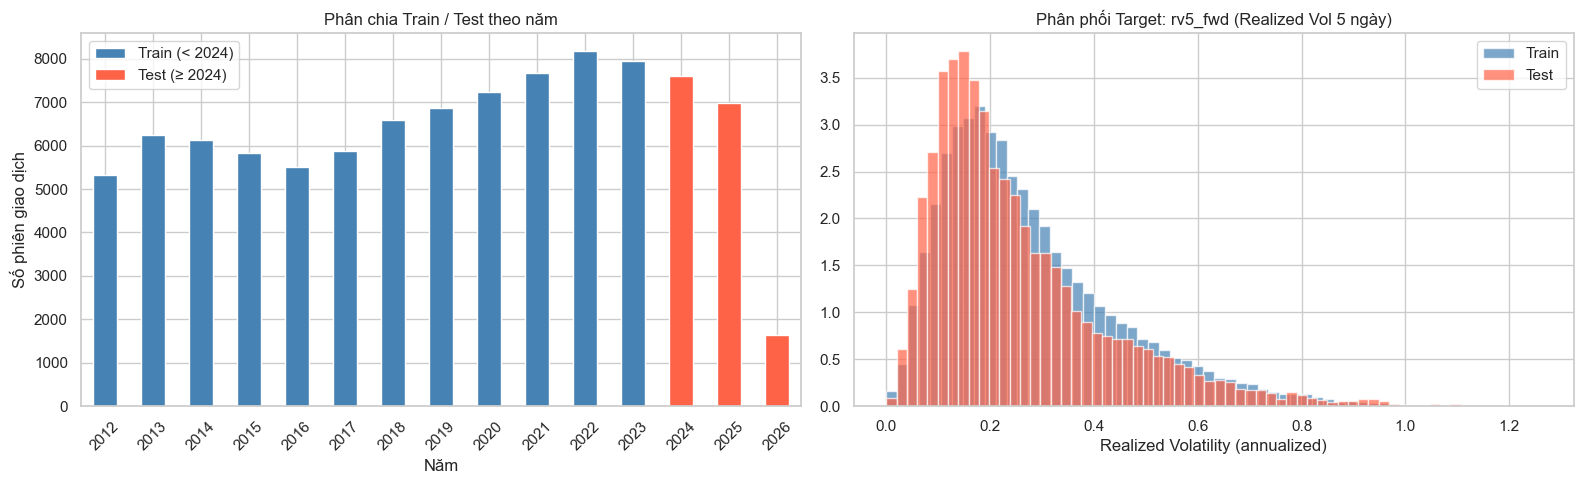

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Train/test split theo năm
counts = df_model.groupby([df_model['date'].dt.year, df_model['date'] >= CUTOFF])['date'].count().unstack()
counts.columns = ['Train (< 2024)', 'Test (≥ 2024)']
counts.index.name = 'Năm'
counts.plot(kind='bar', stacked=True, ax=axes[0],
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Phân chia Train / Test theo năm')
axes[0].set_ylabel('Số phiên giao dịch')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Phân phối target rv5_fwd
axes[1].hist(y_train.values, bins=60, color='steelblue', alpha=0.7, label='Train', density=True)
axes[1].hist(y_test.values,  bins=60, color='tomato',    alpha=0.7, label='Test',  density=True)
axes[1].set_title('Phân phối Target: rv5_fwd (Realized Vol 5 ngày)')
axes[1].set_xlabel('Realized Volatility (annualized)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Huấn luyện mô hình

### 5a. Baseline: HAR-OLS (Corsi, 2009)

Model tham chiếu **bắt buộc phải có**. Chỉ dùng 3 HAR features: `rv_d`, `rv_w`, `rv_m`.  
Dù cực đơn giản, HAR-OLS rất khó bị đánh bại nhờ tính **volatility clustering** mạnh.  
Nếu ML không thắng HAR-OLS → cần thêm feature, không phải thêm model phức tạp.

In [7]:
HAR_FEATURES = ['rv_d', 'rv_w', 'rv_m']

X_train_har = X_train[HAR_FEATURES]
X_test_har  = X_test[HAR_FEATURES]

har_model = LinearRegression()
har_model.fit(X_train_har, y_train)
y_pred_har = har_model.predict(X_test_har)

mae_har  = mean_absolute_error(y_test, y_pred_har)
rmse_har = np.sqrt(mean_squared_error(y_test, y_pred_har))
r2_har   = r2_score(y_test, y_pred_har)
mape_har = np.mean(np.abs((y_test.values - y_pred_har) / np.where(y_test.values == 0, np.nan, y_test.values))) * 100

print('=== HAR-OLS Baseline ===')
print(f'  Coef: rv_d={har_model.coef_[0]:.4f}, rv_w={har_model.coef_[1]:.4f}, rv_m={har_model.coef_[2]:.4f}')
print(f'  Intercept: {har_model.intercept_:.4f}')
print(f'  MAE  : {mae_har:.4f}')
print(f'  RMSE : {rmse_har:.4f}')
print(f'  MAPE : {mape_har:.2f}%')
print(f'  R²   : {r2_har:.4f}')

=== HAR-OLS Baseline ===
  Coef: rv_d=0.1430, rv_w=0.6521, rv_m=0.1799
  Intercept: 0.0564
  MAE  : 0.0764
  RMSE : 0.1048
  MAPE : nan%
  R²   : 0.6440


### 5b. Random Forest Regressor ⭐

Audrino & Knaus (2016) và Naimoli & Storti (2019): RF vượt trội HAR/GARCH trên thị trường mới nổi (1–5 ngày).  
`min_samples_leaf=20` tránh overfit đặc thù của time series. `max_features='sqrt'` theo chuẩn Breiman (2001).  
Robust với outlier — quan trọng cho thị trường VN có nhiều price spike.

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',      # Breiman (2001)
    min_samples_leaf=20,      # tránh overfit trên time series
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test.values - y_pred_rf) / np.where(y_test.values == 0, np.nan, y_test.values))) * 100

print('=== Random Forest ===')
print(f'  MAE  : {mae_rf:.4f}')
print(f'  RMSE : {rmse_rf:.4f}')
print(f'  MAPE : {mape_rf:.2f}%')
print(f'  R²   : {r2_rf:.4f}')

=== Random Forest ===
  MAE  : 0.0658
  RMSE : 0.0931
  MAPE : nan%
  R²   : 0.7191


### 5c. XGBoost Regressor

In [9]:
xgb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test.values - y_pred_xgb) / np.where(y_test.values == 0, np.nan, y_test.values))) * 100

print('=== XGBoost ===')
print(f'  MAE  : {mae_xgb:.4f}')
print(f'  RMSE : {rmse_xgb:.4f}')
print(f'  MAPE : {mape_xgb:.2f}%')
print(f'  R²   : {r2_xgb:.4f}')

=== XGBoost ===
  MAE  : 0.0642
  RMSE : 0.0908
  MAPE : nan%
  R²   : 0.7326


### 5d. LightGBM Regressor

In [10]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)],
)
y_pred_lgb = lgb_model.predict(X_test)

mae_lgb  = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2_lgb   = r2_score(y_test, y_pred_lgb)
mape_lgb = np.mean(np.abs((y_test.values - y_pred_lgb) / np.where(y_test.values == 0, np.nan, y_test.values))) * 100

print('=== LightGBM ===')
print(f'  MAE  : {mae_lgb:.4f}')
print(f'  RMSE : {rmse_lgb:.4f}')
print(f'  MAPE : {mape_lgb:.2f}%')
print(f'  R²   : {r2_lgb:.4f}')

=== LightGBM ===
  MAE  : 0.0628
  RMSE : 0.0894
  MAPE : nan%
  R²   : 0.7411


### 5e. Quantile Random Forest – P10 / P50 / P90 (Meinshausen, 2006)

Dự báo **khoảng tin cậy** — quan trọng nhất cho dashboard rủi ro:
- **P10** = vol kỳ vọng lạc quan (kịch bản tốt nhất)
- **P50** = vol trung bình (con số báo cáo)
- **P90** = vol kỳ vọng xấu → **risk alert**, analyst cần nhất

In [11]:
try:
    from quantile_forest import RandomForestQuantileRegressor

    qrf_model = RandomForestQuantileRegressor(
        n_estimators=500,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1,
    )
    qrf_model.fit(X_train, y_train)

    qrf_preds      = qrf_model.predict(X_test, quantiles=[0.1, 0.5, 0.9])
    y_pred_qrf_p10 = qrf_preds[:, 0]
    y_pred_qrf_p50 = qrf_preds[:, 1]
    y_pred_qrf_p90 = qrf_preds[:, 2]

    mae_qrf  = mean_absolute_error(y_test, y_pred_qrf_p50)
    rmse_qrf = np.sqrt(mean_squared_error(y_test, y_pred_qrf_p50))
    r2_qrf   = r2_score(y_test, y_pred_qrf_p50)
    coverage = np.mean((y_test.values >= y_pred_qrf_p10) & (y_test.values <= y_pred_qrf_p90))

    print('=== Quantile RF (P50 vs Actual) ===')
    print(f'  MAE  : {mae_qrf:.4f}')
    print(f'  RMSE : {rmse_qrf:.4f}')
    print(f'  R²   : {r2_qrf:.4f}')
    print(f'  Coverage P10–P90: {coverage:.1%}  (kỳ vọng ~80%)')
    HAS_QRF = True

except ImportError:
    print('quantile-forest chưa cài. Bỏ qua Quantile RF.')
    HAS_QRF = False
    mae_qrf = rmse_qrf = r2_qrf = np.nan
    y_pred_qrf_p10 = y_pred_qrf_p50 = y_pred_qrf_p90 = np.full(len(y_test), np.nan)

=== Quantile RF (P50 vs Actual) ===
  MAE  : 0.0624
  RMSE : 0.0906
  R²   : 0.7343
  Coverage P10–P90: 81.6%  (kỳ vọng ~80%)


## 6. So sánh kết quả các mô hình

In [12]:
metrics_df = pd.DataFrame({
    'Mô hình':  ['HAR-OLS (Baseline)', 'Random Forest', 'XGBoost', 'LightGBM', 'Quantile RF (P50)'],
    'MAE':      [mae_har,  mae_rf,  mae_xgb,  mae_lgb,  mae_qrf],
    'RMSE':     [rmse_har, rmse_rf, rmse_xgb, rmse_lgb, rmse_qrf],
    'R²':       [r2_har,   r2_rf,   r2_xgb,   r2_lgb,   r2_qrf],
    'MAPE (%)': [mape_har, mape_rf, mape_xgb, mape_lgb, np.nan],
})

display(metrics_df.set_index('Mô hình').style
        .highlight_min(subset=['MAE', 'RMSE'], color='#d4edda')
        .highlight_max(subset=['R²'],           color='#d4edda')
        .highlight_min(subset=['MAPE (%)'],     color='#d4edda')
        .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R²': '{:.4f}', 'MAPE (%)': '{:.2f}'},
                na_rep='—'))

# Ghi chú đọc kết quả
print('\n📌 R² > 0.3 là tốt cho volatility forecasting (rất khó đạt R² cao)')
print('📌 Nếu HAR-OLS thắng ML → thêm feature, không phải thêm model')
print('📌 Coverage P10–P90 ~80% = Quantile RF đáng tin cậy cho dashboard rủi ro')

# Chọn best ML model
scores = {'Random Forest': r2_rf, 'XGBoost': r2_xgb, 'LightGBM': r2_lgb}
best_ml_name = max(scores, key=scores.get)
y_pred_best  = {'Random Forest': y_pred_rf, 'XGBoost': y_pred_xgb, 'LightGBM': y_pred_lgb}[best_ml_name]
print(f'\nBest ML model (R²): {best_ml_name}')

,MAE,RMSE,R²,MAPE (%)
Mô hình,,,,
HAR-OLS (Baseline),0.0764,0.1048,0.6440,—
Random Forest,0.0658,0.0931,0.7191,—
XGBoost,0.0642,0.0908,0.7326,—
LightGBM,0.0628,0.0894,0.7411,—
Quantile RF (P50),0.0624,0.0906,0.7343,—



📌 R² > 0.3 là tốt cho volatility forecasting (rất khó đạt R² cao)
📌 Nếu HAR-OLS thắng ML → thêm feature, không phải thêm model
📌 Coverage P10–P90 ~80% = Quantile RF đáng tin cậy cho dashboard rủi ro

Best ML model (R²): LightGBM


## 7. Feature Importance – Top 15

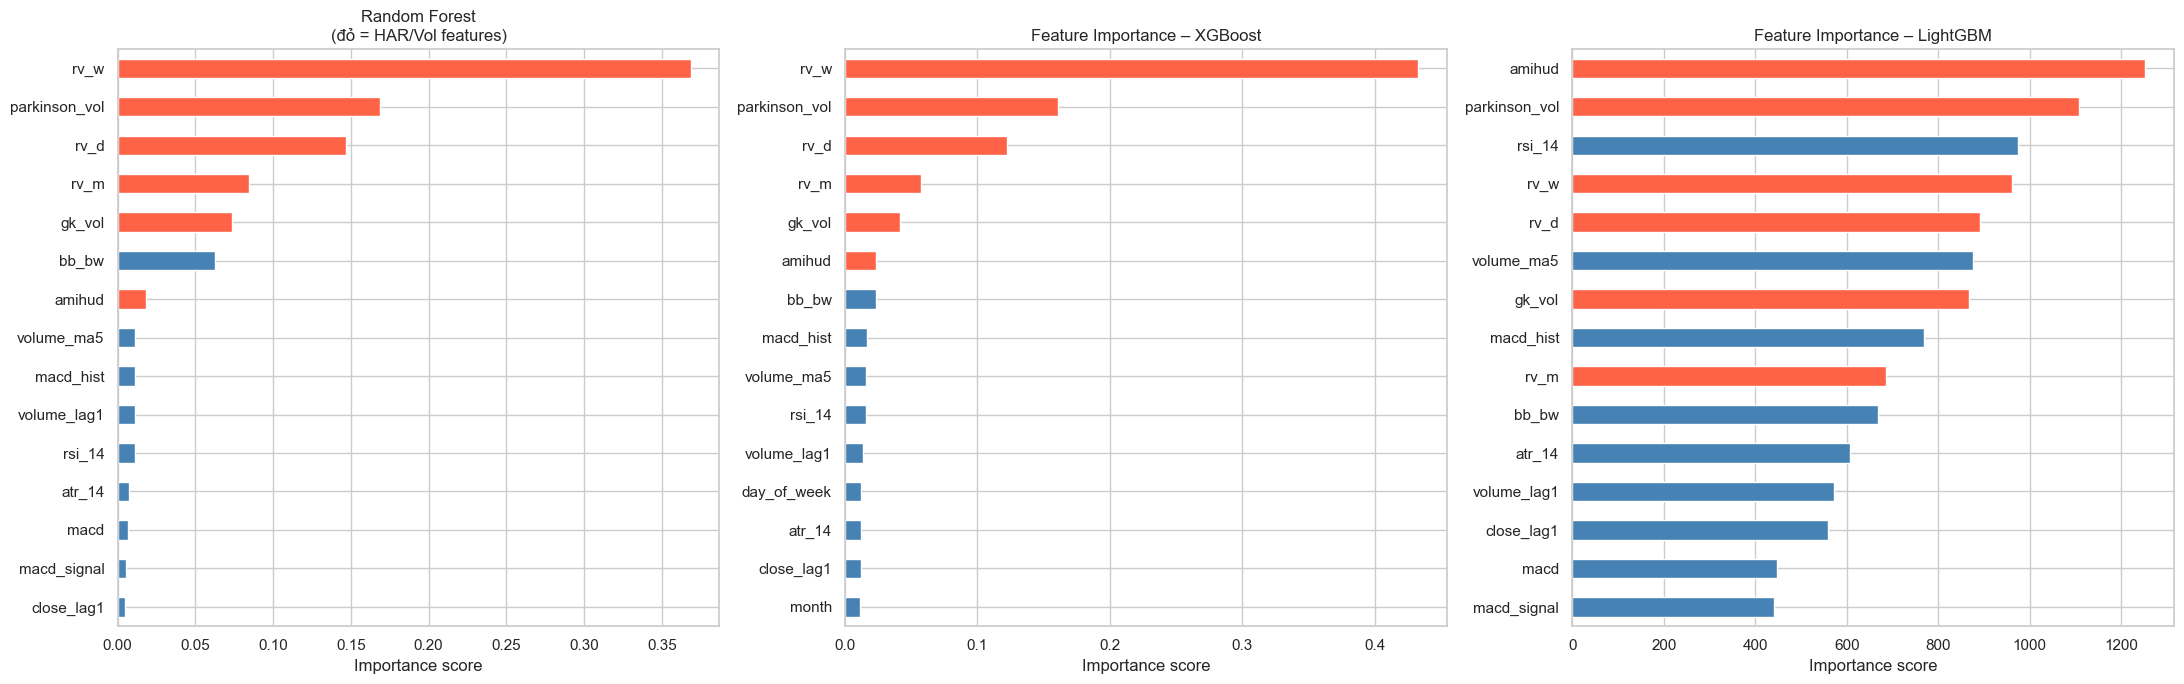


Chú thích màu:
  🔴 Đỏ  = HAR features (rv_d/w/m) + Vol estimators (Parkinson, GK, Amihud)
  🔵 Xanh = Momentum, Lag, Temporal features


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

HAR_RELATED = {'rv_d', 'rv_w', 'rv_m', 'parkinson_vol', 'gk_vol', 'amihud'}

for ax, model, name in [
    (axes[0], rf_model,  'Random Forest'),
    (axes[1], xgb_model, 'XGBoost'),
    (axes[2], lgb_model, 'LightGBM'),
]:
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    imp = imp.sort_values(ascending=True).tail(15)
    colors = ['tomato' if f in HAR_RELATED else 'steelblue' for f in imp.index]
    imp.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Feature Importance – {name}')
    ax.set_xlabel('Importance score')

axes[0].set_title('Random Forest\n(đỏ = HAR/Vol features)')
plt.tight_layout()
plt.show()

print('\nChú thích màu:')
print('  🔴 Đỏ  = HAR features (rv_d/w/m) + Vol estimators (Parkinson, GK, Amihud)')
print('  🔵 Xanh = Momentum, Lag, Temporal features')

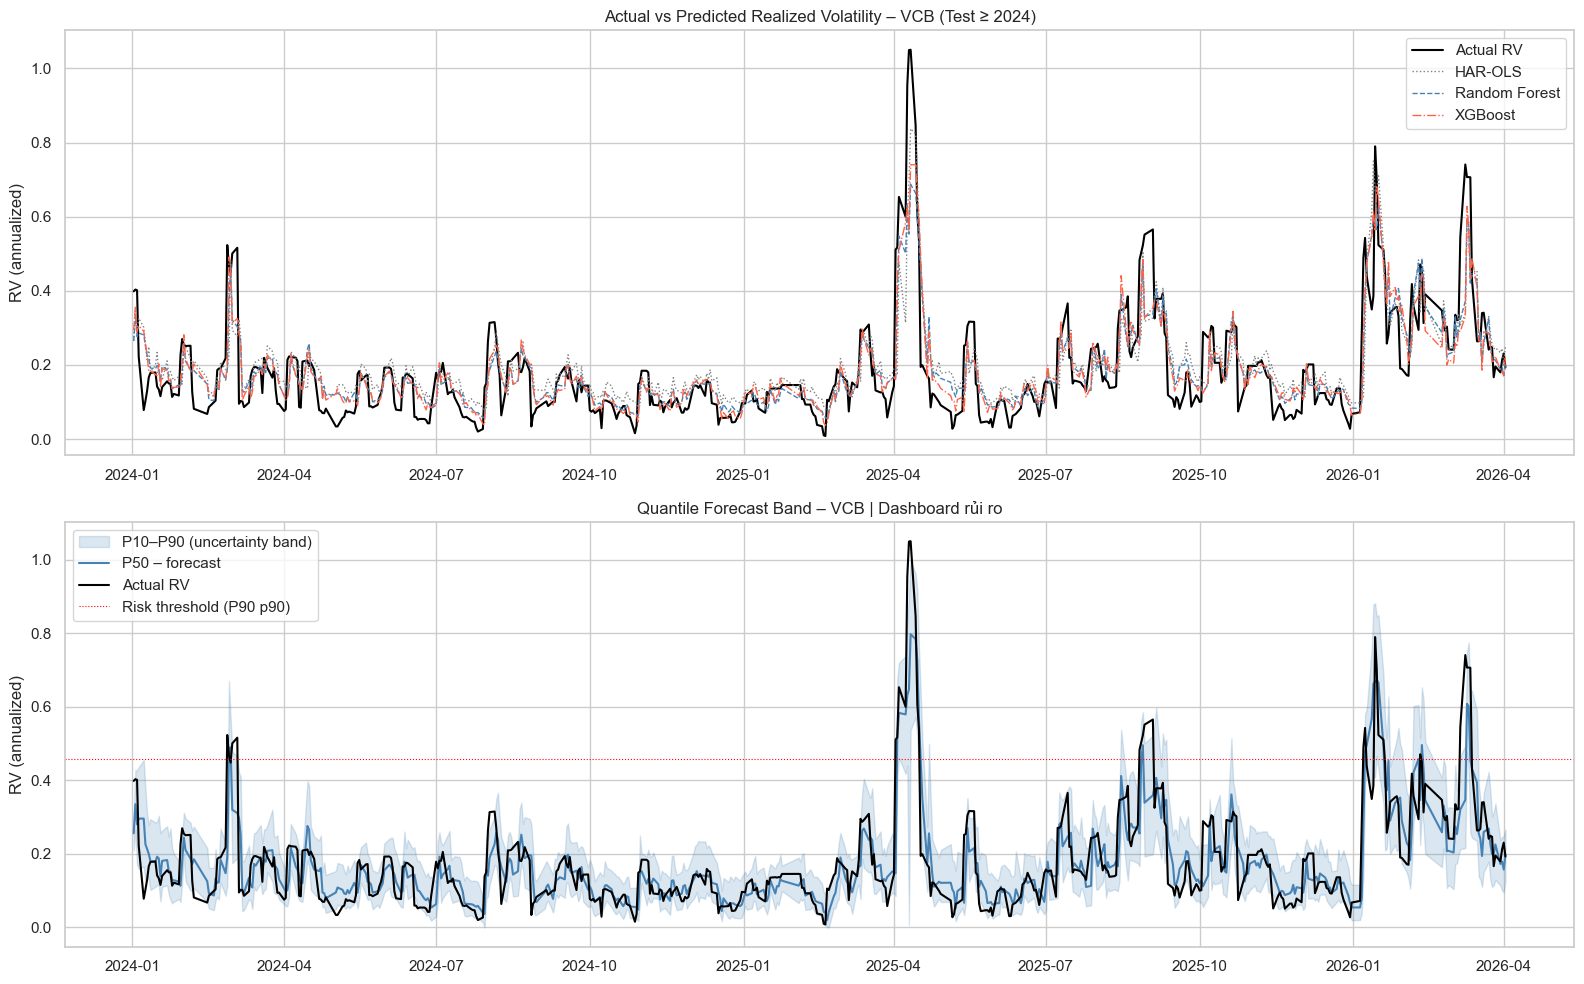

In [14]:
## 8. Dashboard rủi ro – Volatility Forecast với Quantile Band (VCB mẫu)

SAMPLE = 'VCB'

# Gán tất cả predictions vào test DataFrame
test_plot = test.reset_index(drop=True).copy()
test_plot['y_actual'] = y_test.values
test_plot['y_har']    = y_pred_har
test_plot['y_rf']     = y_pred_rf
test_plot['y_xgb']    = y_pred_xgb
test_plot['y_lgb']    = y_pred_lgb
if HAS_QRF:
    test_plot['y_p10'] = y_pred_qrf_p10
    test_plot['y_p50'] = y_pred_qrf_p50
    test_plot['y_p90'] = y_pred_qrf_p90

vcb = test_plot[test_plot['symbol'] == SAMPLE].sort_values('date')

nrows = 2 if HAS_QRF else 1
fig, axes = plt.subplots(nrows, 1, figsize=(16, 5 * nrows))
if nrows == 1:
    axes = [axes]

# Plot 1: Actual vs Predicted (all models)
ax = axes[0]
ax.plot(vcb['date'], vcb['y_actual'], label='Actual RV',     color='black',     linewidth=1.5)
ax.plot(vcb['date'], vcb['y_har'],    label='HAR-OLS',       color='gray',      linewidth=1,  linestyle=':')
ax.plot(vcb['date'], vcb['y_rf'],     label='Random Forest', color='steelblue', linewidth=1,  linestyle='--')
ax.plot(vcb['date'], vcb['y_xgb'],    label='XGBoost',       color='tomato',    linewidth=1,  linestyle='-.')
ax.set_title(f'Actual vs Predicted Realized Volatility – {SAMPLE} (Test ≥ 2024)')
ax.set_ylabel('RV (annualized)')
ax.legend()

# Plot 2: Quantile band dashboard
if HAS_QRF:
    ax2 = axes[1]
    ax2.fill_between(vcb['date'], vcb['y_p10'], vcb['y_p90'],
                     alpha=0.2, color='steelblue', label='P10–P90 (uncertainty band)')
    ax2.plot(vcb['date'], vcb['y_p50'],    label='P50 – forecast',  color='steelblue', linewidth=1.5)
    ax2.plot(vcb['date'], vcb['y_actual'], label='Actual RV',       color='black',     linewidth=1.5)
    ax2.axhline(vcb['y_p90'].quantile(0.9), color='red', linestyle=':', linewidth=0.8, label='Risk threshold (P90 p90)')
    ax2.set_title(f'Quantile Forecast Band – {SAMPLE} | Dashboard rủi ro')
    ax2.set_ylabel('RV (annualized)')
    ax2.legend()

plt.tight_layout()
plt.show()

## 9. Kết luận

### Thay đổi so với phiên bản trước (price prediction → volatility forecasting)

| Mục | Phiên bản cũ | Phiên bản mới |
|---|---|---|
| **Target** | `close_next` (giá tuyệt đối) | `rv5_fwd` (Realized Vol 5 ngày, annualized) |
| **Baseline** | Không có | HAR-OLS (Corsi 2009) |
| **Features** | RSI, MACD, BB, ATR, lag | + HAR (`rv_d/w/m`), Parkinson, Garman-Klass, Amihud |
| **Validation** | Hard cutoff 2024 | `TimeSeriesSplit(n_splits=5, gap=5)` + hard cutoff |
| **Uncertainty** | Không có | Quantile RF (P10 / P50 / P90) |
| **Model count** | 2 (XGBoost, LightGBM) | 5 (HAR-OLS, RF, XGBoost, LightGBM, QRF) |

### Hướng dẫn đọc kết quả

| Kết quả | Ý nghĩa |
|---|---|
| R² > 0.3 | Tốt cho volatility forecasting (R² cao rất khó đạt được trong thực tế) |
| HAR-OLS thắng ML | Dataset thiếu feature xử lý chuỗi; ML cần nhiều feature hơn |
| Coverage P10–P90 ≈ 80% | Quantile RF đáng tin cậy để dùng trong dashboard rủi ro |

### Cải tiến tiếp theo
- Thêm **market-wide features**: VN-Index return, VIX-like measure toàn thị trường
- Thêm **cross-asset features**: spread giữa các mã trong cùng ngành
- Thử **LSTM / Temporal Fusion Transformer** cho seq2seq volatility forecasting
- **Không phải khuyến nghị đầu tư**. Kết quả cần kết hợp phân tích cơ bản và quản trị rủi ro.

In [15]:
## 10. Lưu model ra file

import joblib
from pathlib import Path

SAVE_DIR = Path('saved_models')
SAVE_DIR.mkdir(exist_ok=True)

# HAR-OLS
joblib.dump(har_model, SAVE_DIR / 'har_ols.pkl')

# Random Forest
joblib.dump(rf_model, SAVE_DIR / 'random_forest.pkl')

# XGBoost
xgb_model.save_model(str(SAVE_DIR / 'xgboost.json'))

# LightGBM
lgb_model.booster_.save_model(str(SAVE_DIR / 'lightgbm.txt'))

# Quantile RF (nếu có)
if HAS_QRF:
    joblib.dump(qrf_model, SAVE_DIR / 'quantile_rf.pkl')

# Lưu thêm danh sách feature columns để dùng khi inference
joblib.dump(FEATURE_COLS, SAVE_DIR / 'feature_cols.pkl')

print('Đã lưu model vào thư mục:', SAVE_DIR.resolve())
for f in sorted(SAVE_DIR.iterdir()):
    print(f'  {f.name:30s} {f.stat().st_size / 1024:,.0f} KB')

Đã lưu model vào thư mục: E:\20252\datn\crawler\Volume_precedes_price\saved_models
  feature_cols.pkl               0 KB
  har_ols.pkl                    1 KB
  lightgbm.txt                   1,188 KB
  quantile_rf.pkl                152,979 KB
  random_forest.pkl              136,501 KB
  xgboost.json                   5,330 KB
